# 03 — Fit Gaussian Mixture Model

Fit GMM to preprocessed volume with automatic K selection via BIC. Visualize component distributions.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from research_ct.io.volume_saver import Load_From_Numpy
from research_ct.segmentation.gmm_fitter import Gmm_Fitter
from research_ct.visualization.plot_distributions import plot_gmm_components


In [2]:
# Project directory and data paths
PROJECT_DIR = Path.cwd()

# Find project root directory
while not (PROJECT_DIR / "src").exists():
    PROJECT_DIR = PROJECT_DIR.parent

# Data path
# Load raw data
DATA_DIR = PROJECT_DIR  / "data" 
RAW_DATA_DIR = DATA_DIR / "raw"
OUTPUT_DATA_DIR = DATA_DIR / "output"
FIGURES_DIR = OUTPUT_DATA_DIR / "figures"
DIAG_DIR = OUTPUT_DATA_DIR / "diagnostics"
PROCESSED_DATA_DIR = OUTPUT_DATA_DIR / "processed"

# CHECK IF FIGURES_DIR EXISTS, IF NOT CREATE IT
if not FIGURES_DIR.exists():
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

 



In [3]:
# Load preprocessed volume
Processed = Load_From_Numpy(
    PROCESSED_DATA_DIR / "preprocessed_volume.npz"
    )
Porcessed = Processed > 0         
Shape = Processed.shape
print(f"Loaded: {Shape}")

[Load_From_Numpy] Loaded (lazy): (201, 1734, 1705)  (2.38 GB on disk)
Loaded: (201, 1734, 1705)


## Flatten Data for GMM

GMM operates on 1D intensity values. Each voxel is treated as an independent sample.

In [4]:
Processed = Processed.ravel().reshape(-1, 1)
print(f"Total voxels: {Processed.shape[0]:,}")
print(f"Memory: {Processed.nbytes / 1e9:.2f} GB")

# For very large volumes, sample a subset
if Processed.shape[0] > 1_000_000:
    print("Sampling 5M voxels for faster fitting...")
    Indices = np.random.choice(Processed.shape[0], 300_000, replace=False)
    Sampled = Processed[Indices]
else:
    Sampled = Processed
del Indices


Total voxels: 594,250,470
Memory: 2.38 GB
Sampling 5M voxels for faster fitting...


## Fit GMM with BIC Selection

Test K from 2 to 8. BIC penalizes model complexity — the minimum BIC indicates the best trade-off.

In [5]:
Fitter = Gmm_Fitter(
    Min_Components=2,
    Max_Components=4,
    Covariance_Type="full",
)

Fitter.Fit(Sampled, Verbose=True)

  K=2: BIC=-7.19e+05, converged=True
  K=3: BIC=-1.15e+06, converged=True
  K=4: BIC=-1.17e+06, converged=True
[Gmm_Fitter] Selected K=4


## BIC Scores

Plot BIC vs K to visualize the selection.

In [6]:

fig, ax = plt.subplots(figsize=(8, 5))
K_Range = range(Fitter.Min_Components, Fitter.Max_Components + 1)
ax.plot(K_Range, Fitter.Bic_Scores, 'o-', linewidth=2, markersize=8, color='steelblue')
ax.axvline(Fitter.Num_Components, color='red', linestyle='--', label=f'Selected K={Fitter.Num_Components}')
ax.set_xlabel('Number of Components (K)')
ax.set_ylabel('BIC Score')
ax.set_title('BIC-Based Model Selection')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

plt.savefig(FIGURES_DIR / "BIC-Based Model Selection", dpi=300, bbox_inches="tight")
plt.close()

C:\Users\ORSAdmin\AppData\Local\Temp\ipykernel_26912\1455888606.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Component Distributions

Visualize the fitted Gaussian components against the data histogram.

In [7]:
# Use a smaller sample for plotting (faster)
Plot_Sample = Sampled[np.random.choice(len(Sampled), 100_000, replace=False)].ravel()

fig = plot_gmm_components(Plot_Sample, Fitter.Model)
plt.show()

plt.savefig(FIGURES_DIR / "GMM Components", dpi=300, bbox_inches="tight")
plt.close()



C:\Users\ORSAdmin\AppData\Local\Temp\ipykernel_26912\330512527.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Material Statistics

Extract means, variances, and weights of each component.

In [24]:
Stats = Fitter.Get_Material_Statistics()

print(f"{'Component':<12} {'Mean':<10} {'Variance':<12} {'Weight':<10}")
print("-" * 50)
num_components = len(Stats["Means"])
for k in range(num_components):
    var = Stats["Variances"][k]
    # If variance is an array (per‑feature), reduce to a scalar (e.g., mean of diagonal)
    if isinstance(var, np.ndarray):
        var_scalar = np.mean(var)  # average variance across features
    else:
        var_scalar = var
    print(f"{k:<12} {Stats['Means'][k]:<10.2f} {var_scalar:<12.2f} {Stats['Weights'][k]:<10.4f}")

Component    Mean       Variance     Weight    
--------------------------------------------------
0            0.17       0.00         0.8114    
1            0.00       0.00         0.1008    
2            0.58       0.04         0.0163    
3            0.27       0.00         0.0715    


## Sparse Bayesian GMM — Pruned Overcomplete Fit

Use a Dirichlet-Process GMM to automatically discover the number of active
components. Components with negligible weight or insufficient effective
sample size are pruned.


In [ ]:
from research_ct.segmentation.sparse_bayesian_gmm import Sparse_Bayesian_Gmm

# Fit overcomplete Sparse Bayesian GMM
Sparse_Model = Sparse_Bayesian_Gmm(Max_Components=16, Min_Samples=1000)
Sparse_Model.Fit(Sampled)

# Inspect active component pruning results
Material_Stats = Sparse_Model.Get_Material_Statistics()
print("Active Means:", Material_Stats["Means"])
print("Active Weights:", Material_Stats["Weights"])


## Sparse Bayesian GMM (Alternative K Discovery)

Dirichlet-Process GMM automatically discovers the number of components without BIC scanning. Components with negligible weight are pruned.


In [ ]:
from research_ct.segmentation.sparse_bayesian_gmm import Sparse_Bayesian_Gmm

# Fit overcomplete Sparse Bayesian GMM
Sparse_Model = Sparse_Bayesian_Gmm(
    Max_Components=16,
    Weight_Concentration_Prior=1.0,
    Weight_Threshold=1e-3,
    Min_Samples=1000,
    Covariance_Type="full",
)
Sparse_Model.Fit(Sampled, Verbose=True)

# Inspect active component pruning results
Material_Stats = Sparse_Model.Get_Material_Statistics()
print(f"Active components: {Sparse_Model.Num_Active_Components}/{Sparse_Model.Max_Components}")
print("Active Means:", Material_Stats["Means"])
print("Active Weights:", Material_Stats["Weights"])
print("Active Indices:", Material_Stats["Active_Indices"])


### Compare BIC-GMM vs Sparse Bayesian GMM

Side-by-side comparison of discovered components.


In [ ]:
print(f"BIC-GMM selected K={Fitter.Num_Components}")
print(f"Sparse Bayesian GMM discovered K_active={Sparse_Model.Num_Active_Components}")

# Tabular comparison
print(f"\n{'Method':<25} {'K':<5} {'Means'}")
print("-" * 60)
print(f"{'BIC-GMM':<25} {Fitter.Num_Components:<5} {Stats['Means']}")
print(f"{'Sparse Bayesian GMM':<25} {Sparse_Model.Num_Active_Components:<5} {Material_Stats['Means']}")


## Assign Labels to Full Volume

Use the fitted model to classify every voxel.

In [12]:
import numpy as np
import gc
import os

def write_npy_streaming(path, shape, dtype, chunk_iter):
    """Write a large .npy file via plain sequential writes — no memmap,
    so Windows never accumulates a large resident mapping."""
    with open(path, "wb") as f:
        np.lib.format.write_array_header_2_0(
            f,
            {
                "descr": np.lib.format.dtype_to_descr(np.dtype(dtype)),
                "fortran_order": False,
                "shape": shape,
            },
        )
        for chunk in chunk_iter:
            f.write(np.ascontiguousarray(chunk, dtype=dtype).tobytes())
            f.flush()
            os.fsync(f.fileno())  # force OS to actually write, not just buffer


def chunk_generator():
    for i in range(Num_Chunks):
        start, end = i * Chunk_Size, min((i + 1) * Chunk_Size, N)
        chunk = Processed[start:end]
        chunk_probs = Fitter.Predict_Probabilities(chunk).astype(np.float32, copy=False)
        yield chunk_probs
        del chunk, chunk_probs
        if (i + 1) % 10 == 0:
            gc.collect()
            print(f"Processed {i+1}/{Num_Chunks} chunks")


Chunk_Size = 1_000_000
N = len(Processed)
Num_Chunks = int(np.ceil(N / Chunk_Size))
K = Fitter.Num_Components
probs_path = os.path.join(OUTPUT_DATA_DIR, "gmm_probabilities.npy")
D, H, W = Shape

write_npy_streaming(probs_path, (D, H, W, K), np.float32, chunk_generator())

Processed 10/595 chunks
Processed 20/595 chunks
Processed 30/595 chunks
Processed 40/595 chunks
Processed 50/595 chunks
Processed 60/595 chunks
Processed 70/595 chunks
Processed 80/595 chunks
Processed 90/595 chunks
Processed 100/595 chunks
Processed 110/595 chunks
Processed 120/595 chunks
Processed 130/595 chunks
Processed 140/595 chunks
Processed 150/595 chunks
Processed 160/595 chunks
Processed 170/595 chunks
Processed 180/595 chunks
Processed 190/595 chunks
Processed 200/595 chunks
Processed 210/595 chunks
Processed 220/595 chunks
Processed 230/595 chunks
Processed 240/595 chunks
Processed 250/595 chunks
Processed 260/595 chunks
Processed 270/595 chunks
Processed 280/595 chunks
Processed 290/595 chunks
Processed 300/595 chunks
Processed 310/595 chunks
Processed 320/595 chunks
Processed 330/595 chunks
Processed 340/595 chunks
Processed 350/595 chunks
Processed 360/595 chunks
Processed 370/595 chunks
Processed 380/595 chunks
Processed 390/595 chunks
Processed 400/595 chunks
Processed

## Visualize Segmentation Slices

Inspect how labels map to spatial structure.

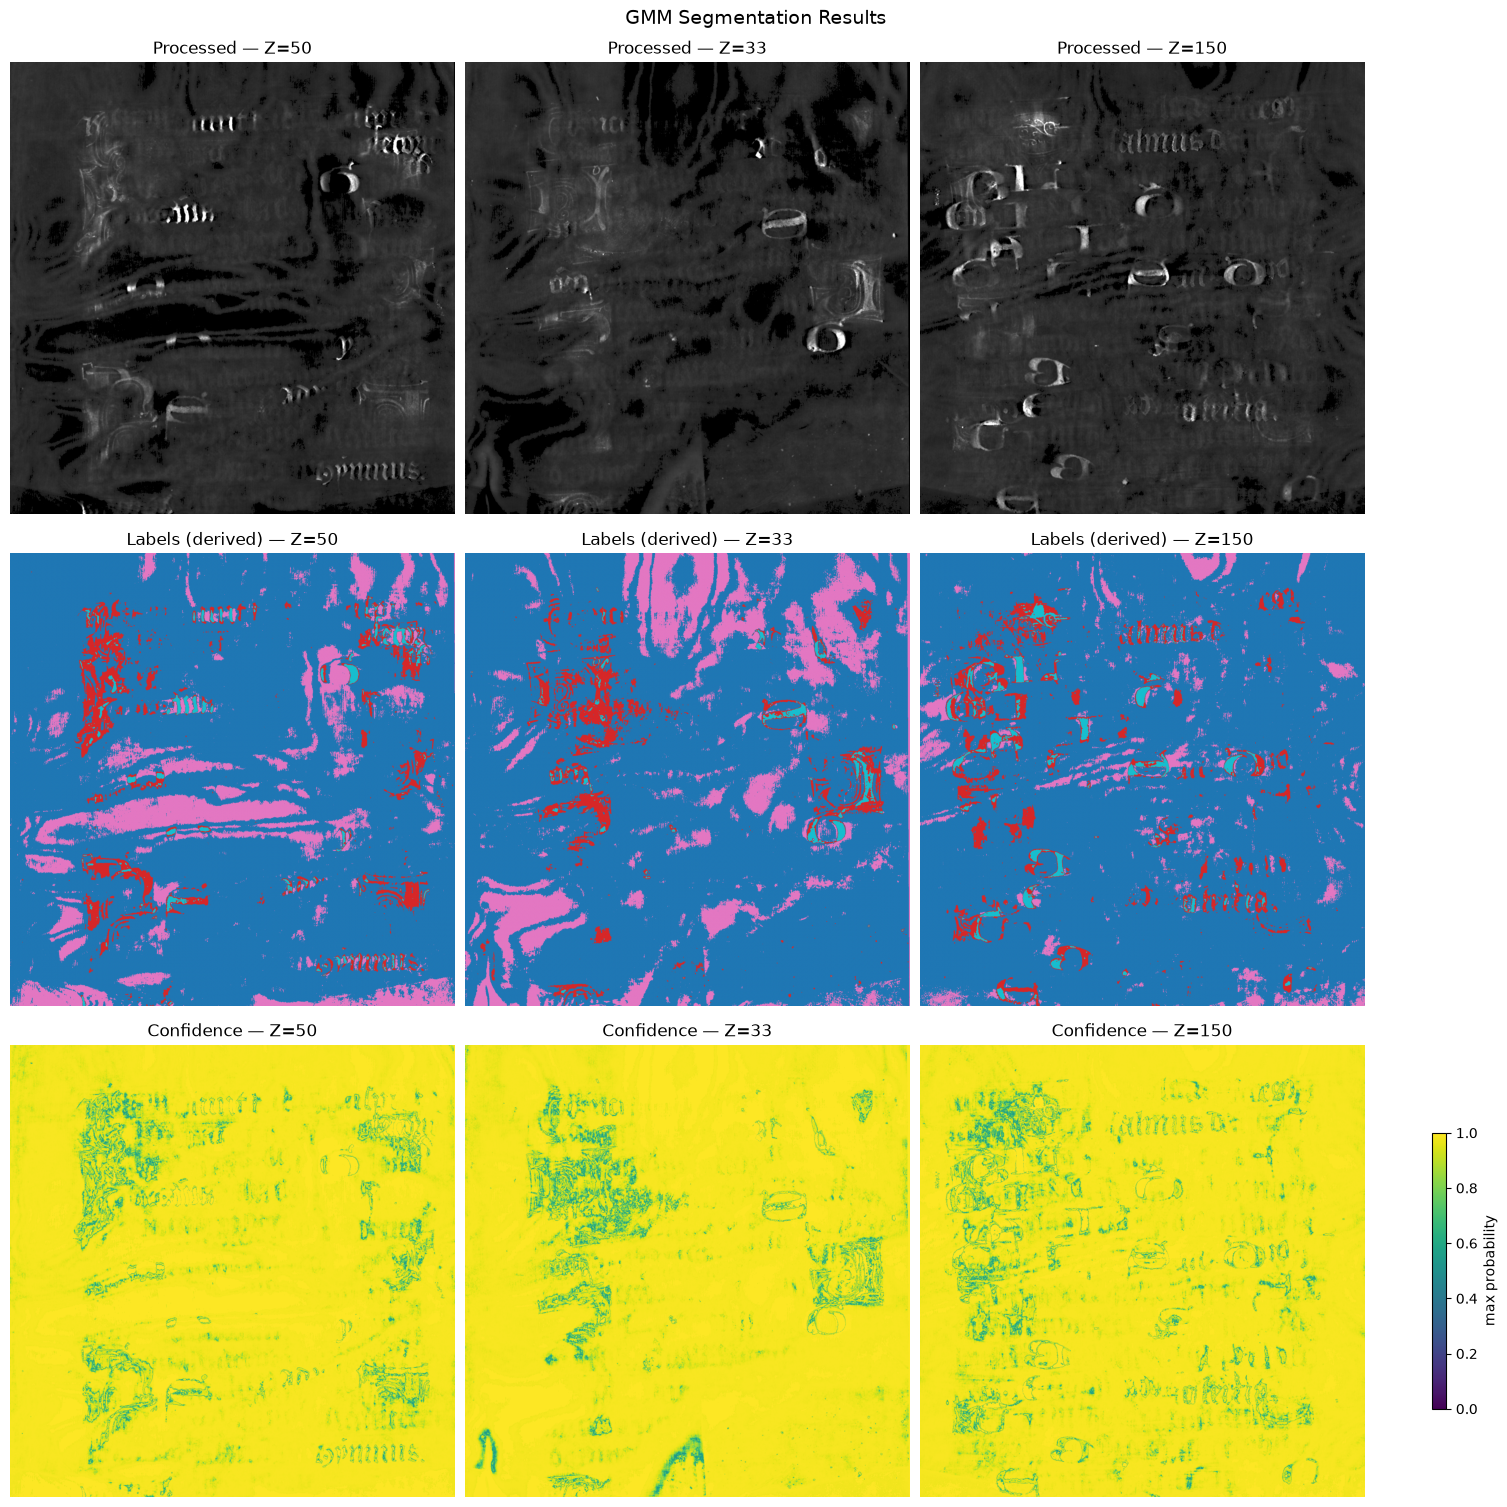

In [13]:
%matplotlib inline

Probs = np.load(
    OUTPUT_DATA_DIR / "gmm_probabilities.npy", mmap_mode="r"
)

D, H, W = Shape

Processed = Processed.ravel().reshape(D, H, W)


fig, axes = plt.subplots(3, 3, figsize=(15, 15), constrained_layout=True)

for i, z in enumerate([D // 4, D // 6, 3 * D // 4]):
    prob_slice = Probs[z]  # only this slice read from disk
    label_slice = prob_slice.argmax(axis=-1)
    conf = prob_slice.max(axis=-1)

    axes[0, i].imshow(Processed[z], cmap="gray")
    axes[0, i].set_title(f"Processed — Z={z}")
    axes[0, i].axis("off")

    axes[1, i].imshow(label_slice, cmap="tab10", vmin=0, vmax=Fitter.Num_Components - 1)
    axes[1, i].set_title(f"Labels (derived) — Z={z}")
    axes[1, i].axis("off")

    im = axes[2, i].imshow(conf, cmap="viridis", vmin=0, vmax=1)
    axes[2, i].set_title(f"Confidence — Z={z}")
    axes[2, i].axis("off")

fig.colorbar(im, ax=axes[2, :], shrink=0.6, label="max probability")
plt.suptitle("GMM Segmentation Results", fontsize=14)
plt.show()

## Save Results

Store labels and probabilities for HMRF and visualization.

In [14]:
from research_ct.io.volume_saver import Save_As_Numpy

Save_As_Numpy(Probs.astype(np.float32), OUTPUT_DATA_DIR / "gmm_probabilities.npz")

print(f"Saved to {OUTPUT_DATA_DIR / 'gmm_probabilities.npz'}")

[Save_As_Numpy] Saved -> c:\Users\ORSAdmin\Documents\Gabriel\research_ct\data\output\gmm_probabilities.npz
Saved to c:\Users\ORSAdmin\Documents\Gabriel\research_ct\data\output\gmm_probabilities.npz
